Total number of conversations in the dataset: 5244


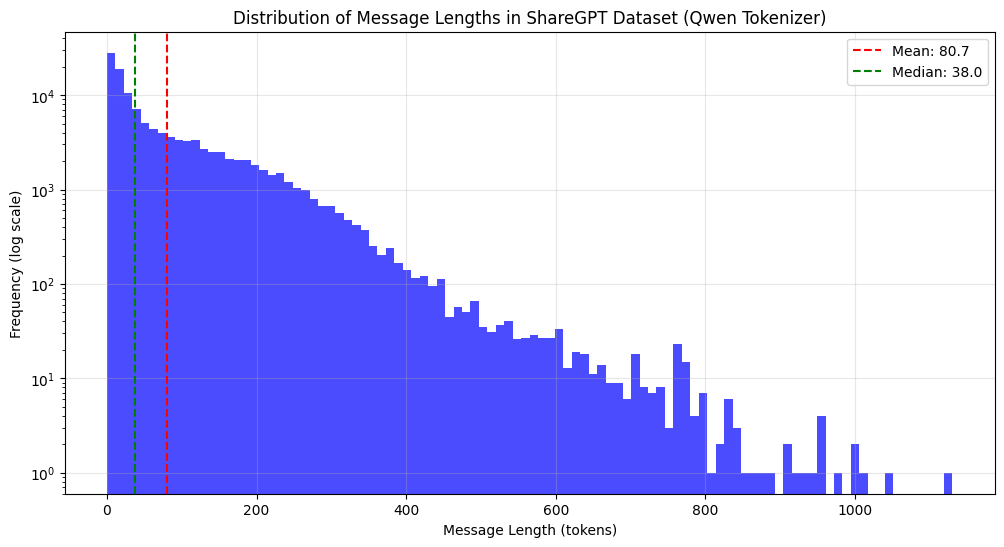

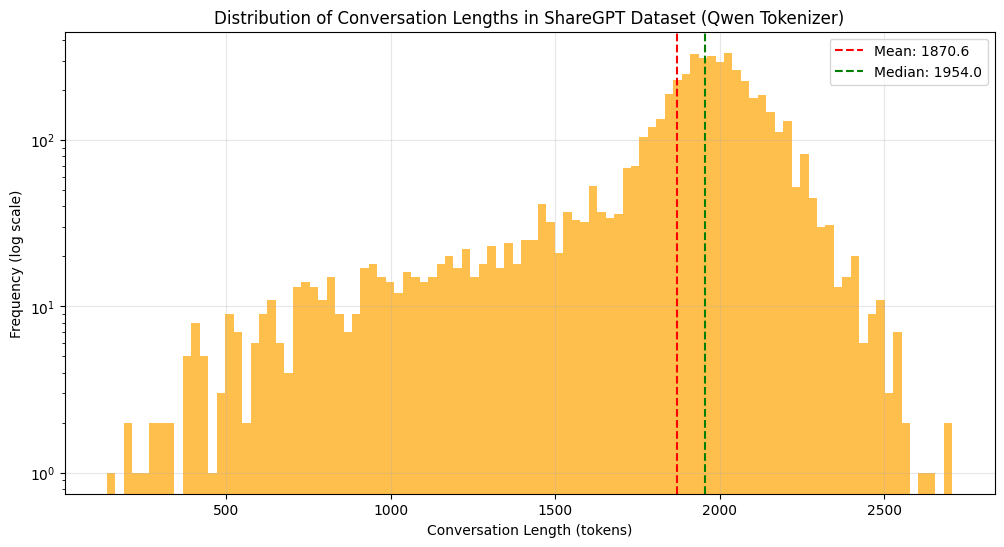


Message length statistics (characters):
Min: 0, Max: 5008
Mean: 373.5, Median: 167.0
Number of messages: 121486

Message length statistics (tokens):
Min: 0, Max: 1130
Mean: 80.7, Median: 38.0
Number of messages: 121486

Conversation length statistics (characters):
Min: 308, Max: 13653
Mean: 8652.9, Median: 9045.0
Number of conversations: 5244

Conversation length statistics (tokens):
Min: 138, Max: 2706
Mean: 1870.6, Median: 1954.0
Number of conversations: 5244

Messages per conversation: 23.2 (average)


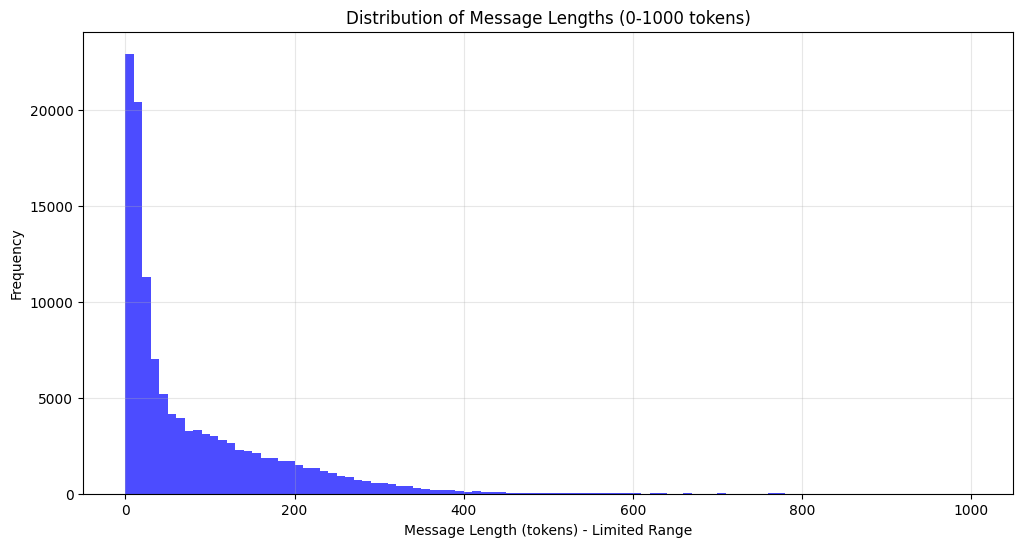

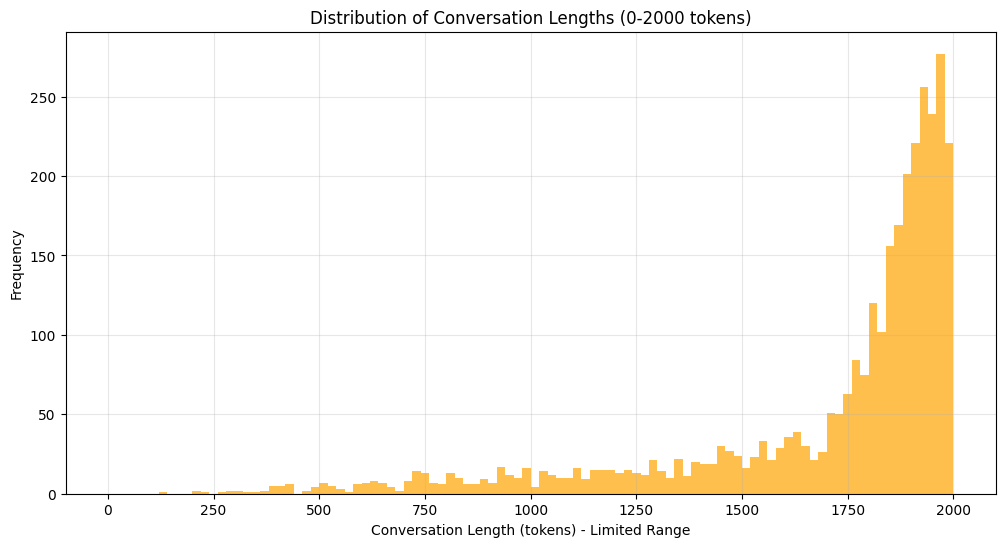

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np
from benchmark import download_and_cache_file
from transformers import AutoTokenizer

# Download and load the ShareGPT dataset
dataset = json.load(open("/home/ray/default/work/ray/prefix_aware_playground/current_work/sharegpt.json"))

print(f"Total number of conversations in the dataset: {len(dataset)}")

# Load Qwen tokenizer
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")

# Collect message and conversation lengths in both characters and tokens
message_char_lengths = []
message_token_lengths = []
conversation_char_lengths = []
conversation_token_lengths = []

for conversation in dataset:
    if 'conversations' in conversation:
        conv_char_length = 0
        conv_token_length = 0
        for message in conversation['conversations']:
            msg_text = message.get('value', '')
            msg_char_length = len(msg_text)
            msg_token_length = len(tokenizer.encode(msg_text))
            
            message_char_lengths.append(msg_char_length)
            message_token_lengths.append(msg_token_length)
            
            conv_char_length += msg_char_length
            conv_token_length += msg_token_length
        
        if conv_char_length > 0:
            conversation_char_lengths.append(conv_char_length)
            conversation_token_lengths.append(conv_token_length)

# Plot message length distribution in tokens
plt.figure(figsize=(12, 6))
plt.hist(message_token_lengths, bins=100, alpha=0.7, color='blue', log=True)
plt.xlabel('Message Length (tokens)')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution of Message Lengths in ShareGPT Dataset (Qwen Tokenizer)')
plt.grid(True, alpha=0.3)
plt.axvline(np.mean(message_token_lengths), color='red', linestyle='dashed', label=f'Mean: {np.mean(message_token_lengths):.1f}')
plt.axvline(np.median(message_token_lengths), color='green', linestyle='dashed', label=f'Median: {np.median(message_token_lengths):.1f}')
plt.legend()
plt.show()

# Plot conversation length distribution in tokens
plt.figure(figsize=(12, 6))
plt.hist(conversation_token_lengths, bins=100, alpha=0.7, color='orange', log=True)
plt.xlabel('Conversation Length (tokens)')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution of Conversation Lengths in ShareGPT Dataset (Qwen Tokenizer)')
plt.grid(True, alpha=0.3)
plt.axvline(np.mean(conversation_token_lengths), color='red', linestyle='dashed', label=f'Mean: {np.mean(conversation_token_lengths):.1f}')
plt.axvline(np.median(conversation_token_lengths), color='green', linestyle='dashed', label=f'Median: {np.median(conversation_token_lengths):.1f}')
plt.legend()
plt.show()

# Print statistics for both characters and tokens
print(f"\nMessage length statistics (characters):")
print(f"Min: {min(message_char_lengths)}, Max: {max(message_char_lengths)}")
print(f"Mean: {np.mean(message_char_lengths):.1f}, Median: {np.median(message_char_lengths):.1f}")
print(f"Number of messages: {len(message_char_lengths)}")

print(f"\nMessage length statistics (tokens):")
print(f"Min: {min(message_token_lengths)}, Max: {max(message_token_lengths)}")
print(f"Mean: {np.mean(message_token_lengths):.1f}, Median: {np.median(message_token_lengths):.1f}")
print(f"Number of messages: {len(message_token_lengths)}")

print(f"\nConversation length statistics (characters):")
print(f"Min: {min(conversation_char_lengths)}, Max: {max(conversation_char_lengths)}")
print(f"Mean: {np.mean(conversation_char_lengths):.1f}, Median: {np.median(conversation_char_lengths):.1f}")
print(f"Number of conversations: {len(conversation_char_lengths)}")

print(f"\nConversation length statistics (tokens):")
print(f"Min: {min(conversation_token_lengths)}, Max: {max(conversation_token_lengths)}")
print(f"Mean: {np.mean(conversation_token_lengths):.1f}, Median: {np.median(conversation_token_lengths):.1f}")
print(f"Number of conversations: {len(conversation_token_lengths)}")

# Calculate average messages per conversation
messages_per_conversation = [len(conv['conversations']) for conv in dataset if 'conversations' in conv]
print(f"\nMessages per conversation: {np.mean(messages_per_conversation):.1f} (average)")

# Add histograms with limited range to see distribution better (tokens)
plt.figure(figsize=(12, 6))
plt.hist(message_token_lengths, bins=100, alpha=0.7, color='blue', range=(0, 1000))
plt.xlabel('Message Length (tokens) - Limited Range')
plt.ylabel('Frequency')
plt.title('Distribution of Message Lengths (0-1000 tokens)')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.hist(conversation_token_lengths, bins=100, alpha=0.7, color='orange', range=(0, 2000))
plt.xlabel('Conversation Length (tokens) - Limited Range')
plt.ylabel('Frequency')
plt.title('Distribution of Conversation Lengths (0-2000 tokens)')
plt.grid(True, alpha=0.3)
plt.show()
